# AP 155 Lab Exercise
---
## Exercise 4
: Derivatives

_Instructions_: 
- **Output 1: Finite Difference** Functions and plots of finite-difference methods
- **Output 2: Harmonic Oscillator** Error analysis plot of finite-difference methods.
  
### Student Information
- _Full Name (Last Name, First Name)_: Abellana, Karl Gian
- _Student No._: 2024-09545
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

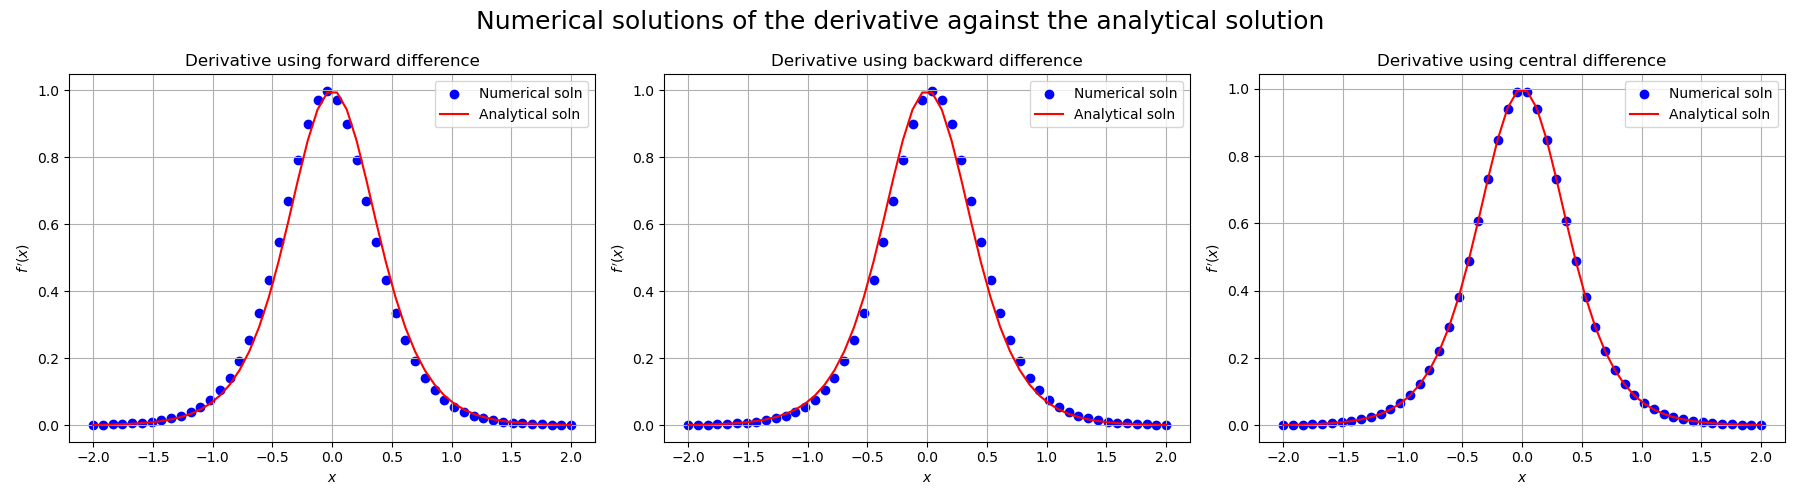

Figure 1

Figure 1 plots the different ways you can numerically solve for the derivative of a function; via forward difference, backward difference, and central difference. On the numerical calculation using forward difference, notice that the points are slightly higher than the analytical solution when the derivative increases, and slightly lower when the derivative decreases. This is due to the forward bias of the forward difference, i.e., it exaggerates the slope to the positive direction. Similarly, the backward difference dots are slightly lower when the derivative increases, and slightly higher when the derivative decreases. This is due to to to the backward difference exaggerating the slope to the negative direction. From this, we can imagine that the central difference is a better approximation because it looks forward and backward at an equal magnitude, and this is supported by our plot on the right, where the dots are nearly aligned to the analytical solution.

### Problem 2 
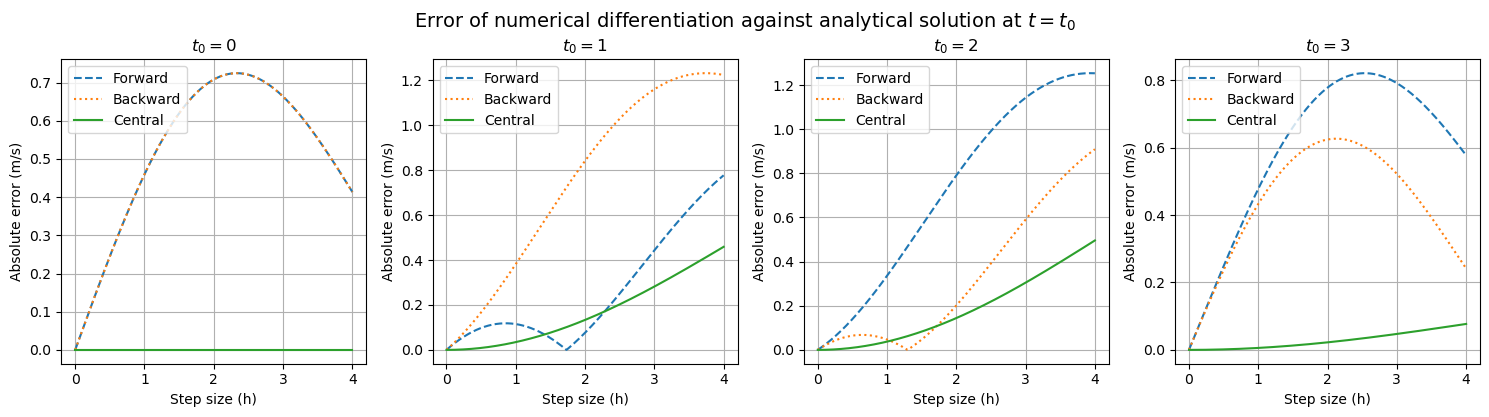
Figure 2

Figure 2 plots the absolute error of the numerical calulation (using backward difference and central difference)

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

### Problem 1: Finite Difference

Let $$f(x) = 1+\frac{1}{2}\tanh(2x)$$

**(a)** Create functions that take as input an array or list of points corresponding to a mathematical function and output the derivative using **(a.1)** forward-difference, **(a.2)** backward-difference, and **(a.3)** central-difference methods.


In [6]:
# libs
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# code here
# forward difference: f(x+h)-f(x)/h
def fwdDiffDerivative(x, func, h):
    return (func(x+h) - func(x))/h

# backward difference: f(x)-f(x-h)/h
def bckDiffDerivative(x, func, h):
    return (func(x)-func(x-h))/h

# central difference: f(x+h/2) - f(x-h/2)/h
def cntrDiffDerivative(x, func, h):
    return (func(x+h/2) - func(x-h/2))/h

**(b)** Calculate an analytic formula for the derivative. Make three subplots for the derivative of $f'(x)$, one for each method and the analytic answer on the same plots. Plot the exact answer (use `numpy`) as lines and the numerical one as dots. Describe how the two results compare. Use `plt.subplots`

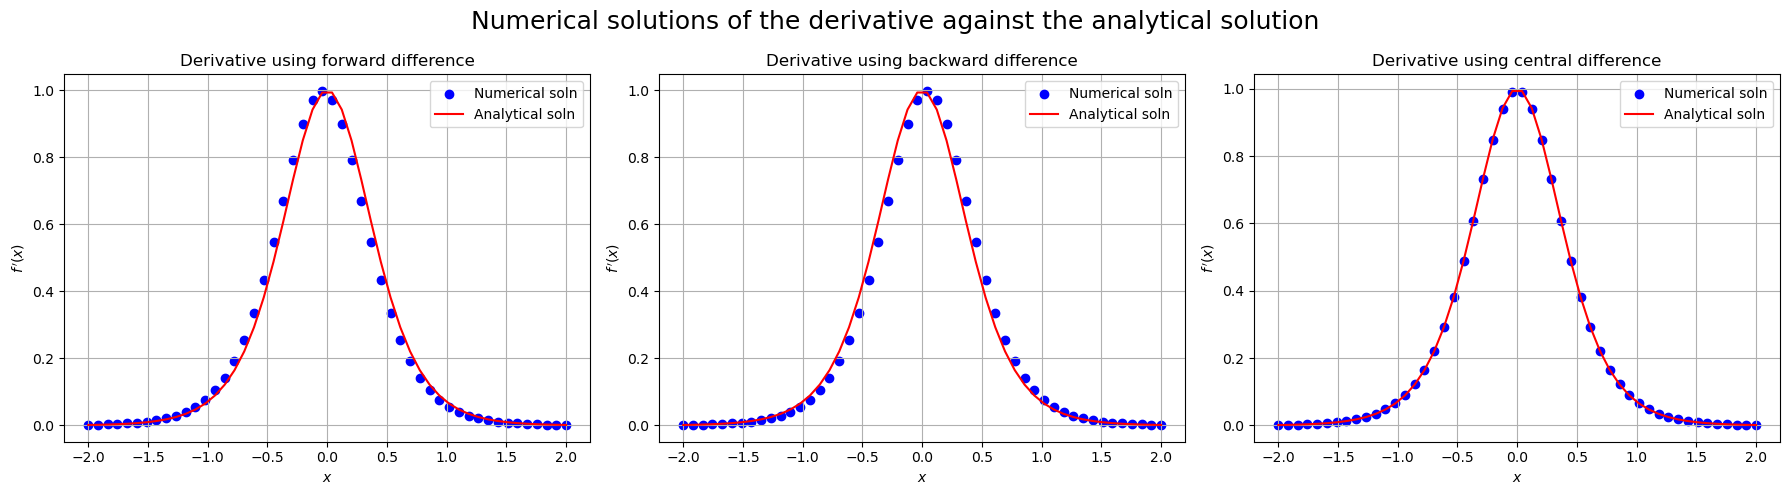

In [2]:
# KOWD HIR

# our function
def fx(x):
    return 1+(1/2*np.tanh(2*x))

# analytic derivative
def fxAnalyticDerivative(x):
    return (1/np.cosh(2*x))**2

# thing we wanna plot [-2, 2] with n=50 points
xs = np.linspace(-2, 2, num = 50, endpoint = True, dtype = float)
h = xs[1]-xs[0]

# plot setup
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for i in ax: i.grid(True) 

# plotting forward difference against analytic soln
ax[0].scatter(xs, fwdDiffDerivative(xs, fx, h), color = 'blue', label = "Numerical soln")
ax[0].plot(xs, fxAnalyticDerivative(xs), color = 'red', label = "Analytical soln")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$f\,'(x)$")
ax[0].set_title("Derivative using forward difference")
ax[0].legend()

# plotting backward difference against analytic solnax[0].scatter(xs, fwdDiffDerivative(xs, fx), color = 'blue', label = "Numerical soln")
ax[1].scatter(xs, bckDiffDerivative(xs, fx, h), color = 'blue', label = "Numerical soln")
ax[1].plot(xs, fxAnalyticDerivative(xs), color = 'red', label = "Analytical soln")
ax[1].set_xlabel("$x$")
ax[1].set_ylabel("$f\,'(x)$")
ax[1].set_title("Derivative using backward difference")
ax[1].legend()

# plotting backward difference against analytic solnax[0].scatter(xs, fwdDiffDerivative(xs, fx), color = 'blue', label = "Numerical soln")
ax[2].scatter(xs, cntrDiffDerivative(xs, fx, h), color = 'blue', label = "Numerical soln")
ax[2].plot(xs, fxAnalyticDerivative(xs), color = 'red', label = "Analytical soln")
ax[2].set_xlabel("$x$")
ax[2].set_ylabel("$f\,'(x)$")
ax[2].set_title("Derivative using central difference")
ax[2].legend()

fig.suptitle("Numerical solutions of the derivative against the analytical solution", fontsize = 18)
fig.tight_layout()
plt.savefig("Problem 1.png")
plt.show()

#### Problem 1 code summary

For the different methods of calculating derivatives, I decided to make it three separate functions and calculate the step from there. As prophylaxis for Problem 2, I decided to make the step ```h``` an argument. The next steps are simple, making use of numpy arrays, calling a function with an array argument returns an output array. So defining the function, and its derivative analytically, we can easily plot the values and compare it to the numerical solution.

### Problem 2: Simple Harmonic Oscillator

The position $x(t)$ of a 1D simple harmonic oscillator is described by the equation of motion:

$$-kx = \frac{d^2x}{dt^2}$$

We know a solution can take the form of $x(t) = \cos(t)$. Calculate the velocity of this particle using any finite-difference method, and plot its absolute error with respect to the analytical value by varying your step-sizes. The absolute error should have the same trend as the $\mathcal{O}$ error of your chosen method.

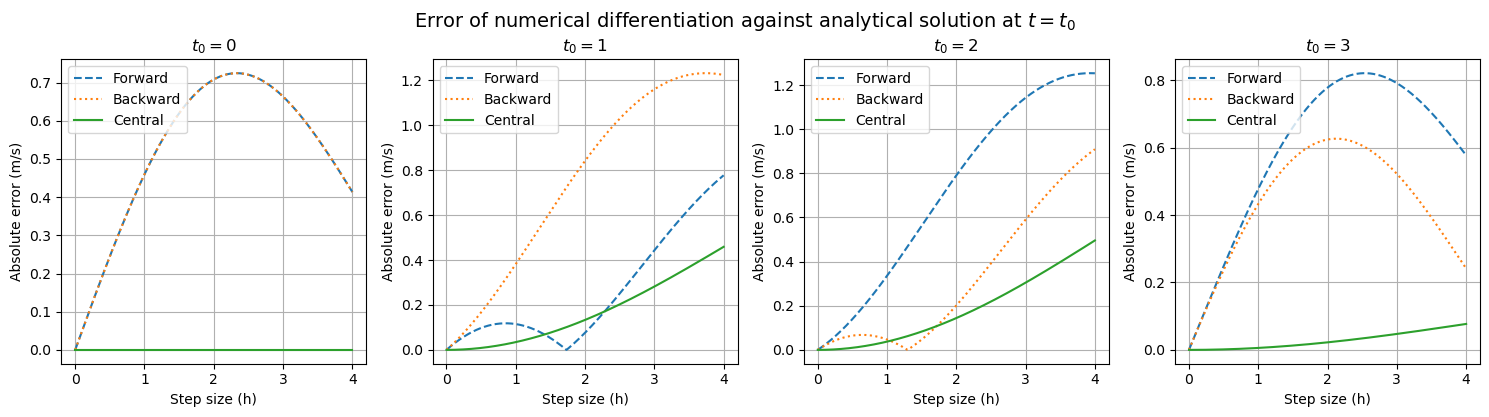

In [5]:
# code
# position
def xt(t):
    return np.cos(t)
# velocity analytical soln
def vtAnalytical(t):
    return -np.sin(t)

h_values = np.linspace(0.001,4,500)
fig, ax = plt.subplots(1, 4, figsize=(15,4))

for i in range(len(ax)):
    t0 = i
    # backward difference and forward difference velocities at t = t0
    v_fwd = fwdDiffDerivative(t0, xt, h_values)
    v_bck = bckDiffDerivative(t0, xt, h_values)
    v_cntr = cntrDiffDerivative(t0, xt, h_values)
    
    # true value (not sponsored)
    v_analytical = vtAnalytical(t0)
    
    # calculate absolute errors
    error_fwd = np.abs(v_fwd - v_analytical)
    error_bck = np.abs(v_bck - v_analytical)
    error_cntr = np.abs(v_cntr - v_analytical)
    
    # plot
    ax[i].plot(h_values, error_fwd, label = "Forward", linestyle = 'dashed')
    ax[i].plot(h_values, error_bck, label = "Backward", linestyle = 'dotted')
    ax[i].plot(h_values, error_cntr, label = "Central")
    ax[i].grid()
    ax[i].legend(loc = "upper left")
    ax[i].set_xlabel("Step size (h)")
    ax[i].set_ylabel("Absolute error (m/s)")
    ax[i].set_title(f"$t_0 = {i}$")

fig.tight_layout()
fig.suptitle("Error of numerical differentiation against analytical solution at $t = t_0$", fontsize = 14, y = 1.03)
plt.savefig("Problem 2.png", bbox_inches="tight")
plt.show()

#### Problem 2 code summary

Using the functions we defined earlier: ```bckDiffDerivative()``` and ```cntrDiffDerivative()```, we calculate the velocity at test point $t = t_0 = 1$. We generate a bunch of steps using np.linspace because we want to see how the error behaves as the step size grows. This is then plotted using matplotlib.

---
## Section 3: Tutorials

### Derivatives

The derivate of a function $f(x) $ can be approximated using the **forward difference** as

$$f'(x) = \frac{f(x+h) - f(x)}{h} + \mathcal{O}(h)$$

using the **backward difference**

$$f'(x) = \frac{f(x) - f(x-h)}{h} + \mathcal{O}(h)$$

and the **central difference**

$$f'(x) = \frac{f(x + \frac{h}{2}) - f(x - \frac{h}{2})}{h} + \mathcal{O}(h^2)$$

where $h$ is a small step-size. To minimzie error, you can use Richardson Extrapolation, which can be found on the book (Gezerlis).

### Floating-point representation

Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

### Basics

In [ ]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

In [ ]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

### Control flow

In [ ]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

In [ ]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

In [ ]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

In [ ]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

### Data structures

In [ ]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

In [ ]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

In [ ]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

In [ ]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

In [ ]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

In [ ]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

In [ ]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

In [ ]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

### User-defined functions

In [ ]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

In [ ]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

In [ ]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions

"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [ ]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

In [ ]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

In [ ]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [ ]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

In [ ]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments